<a href="https://colab.research.google.com/github/isha3456/Isha-/blob/main/Task10/07/26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.processing import StandardScaler,LabelEncoder
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,r2_score,mean_squared_error
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier



--- Step 1: Generating Raw Data ---
Dataset generated successfully with 500 rows and 19 features.

--- Step 2: Data Preprocessing ---
Data Cleaning & Label Encoding completed.

--- Step 3: Triggering Visualizations (EDA) ---


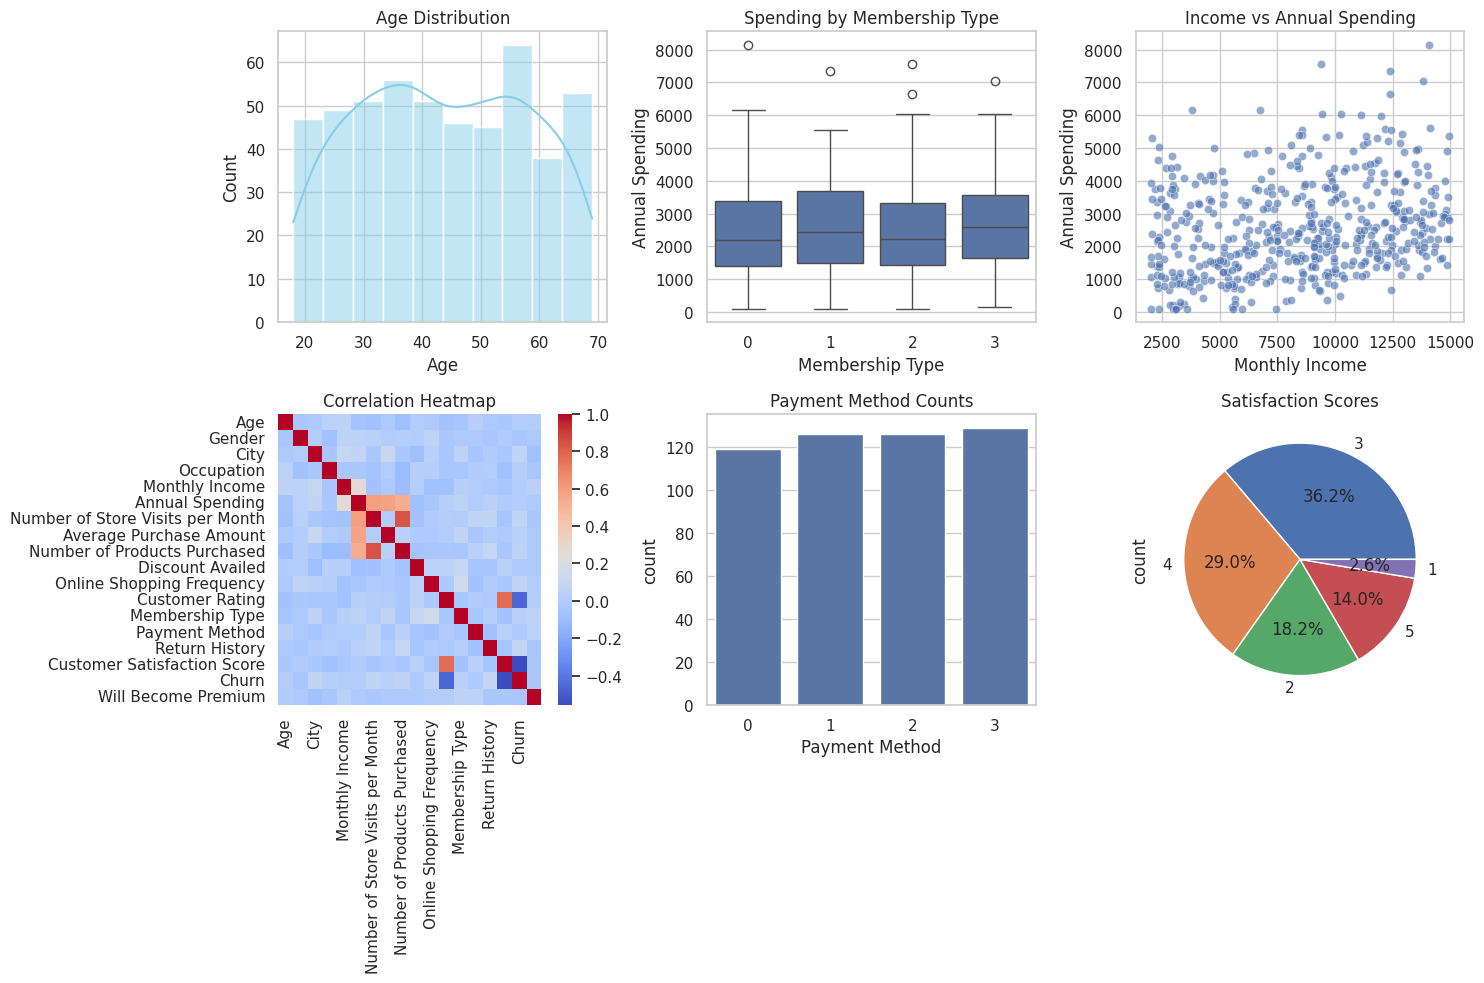

--- Step 4: K-Means Clustering ---


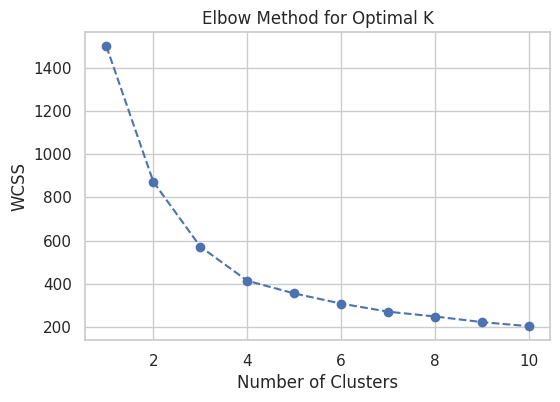

Clustering completed. Customer segments added to dataset.
Cluster Label
Budget Customers        139
Premium Customers       138
Occasional Customers    114
Regular Customers       109
Name: count, dtype: int64 

--- Step 5: Training Supervised Models ---
[Linear Regression] R² Score: 0.8654, MAE: $418.47
[Logistic Regression] Prediction Accuracy: 92.00%
[Random Forest Classifier] Churn Prediction Accuracy: 92.00%

              SUPERMARKET INTELLIGENCE DASHBOARD            
Total Active Customer Base Analyzed: 500

--- Model Evaluation Summary Metrics ---
1. Spending Predictor (Linear Reg)  | R² Score : 0.87 | MAE: $418.47
2. Premium Targeter (Logistic Reg)  | Accuracy : 92.0%
3. Churn Risk Engine (Random Forest)| Accuracy : 92.0%
------------------------------------------------------------
Simulating generation for a new customer account...

************************* CUSTOMER INTELLIGENCE REPORT *************************
• Assigned Market Segment       : Budget Customers (Cluster Prof

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

# Set random seed for reproducibility
np.random.seed(42)
sns.set_theme(style="whitegrid")

# ==========================================
# STEP 1: DATASET GENERATION (Lists & Dicts)
# ==========================================
print("--- Step 1: Generating Raw Data ---")
num_customers = 500

raw_data = []
cities = ["New York", "Los Angeles", "Chicago", "Houston", "Miami"]
occupations = ["Engineer", "Teacher", "Doctor", "Artist", "Manager", "Student"]
membership_types = ["Bronze", "Silver", "Gold", "Platinum"]
payment_methods = ["Cash", "Credit Card", "Debit Card", "UPI"]

for i in range(1, num_customers + 1):
    age = int(np.random.randint(18, 70))
    monthly_income = float(np.random.randint(2000, 15000))
    visits = int(np.random.randint(1, 20))
    avg_purchase = float(np.random.uniform(10, 300))
    products_purchased = int(visits * np.random.randint(2, 6))

    # Introduce correlation for annual spending
    annual_spending = (monthly_income * 0.12) + (visits * avg_purchase) + np.random.normal(0, 500)
    annual_spending = max(100, float(annual_spending)) # Ensure positive

    # Logic-based dependent variables
    rating = float(np.clip(np.random.normal(3.8, 0.8), 1, 5))
    satisfaction_score = int(np.clip(rating + np.random.choice([-1, 0, 1], p=[0.2, 0.6, 0.2]), 1, 5))
    churn = 1 if satisfaction_score <= 2 else int(np.random.choice([0, 1], p=[0.85, 0.15]))
    will_become_premium = 1 if annual_spending > 8000 and rating > 4.0 else int(np.random.choice([0, 1], p=[0.9, 0.1]))

    customer_dict = {
        "Customer ID": f"CUST_{1000 + i}",
        "Age": age,
        "Gender": np.random.choice(["Male", "Female"]),
        "City": np.random.choice(cities),
        "Occupation": np.random.choice(occupations),
        "Monthly Income": monthly_income,
        "Annual Spending": annual_spending,
        "Number of Store Visits per Month": visits,
        "Average Purchase Amount": avg_purchase,
        "Number of Products Purchased": products_purchased,
        "Discount Availed": np.random.choice(["Yes", "No"], p=[0.4, 0.6]),
        "Online Shopping Frequency": np.random.choice(["Rarely", "Occasionally", "Frequently"]),
        "Customer Rating": round(rating, 1),
        "Membership Type": np.random.choice(membership_types),
        "Payment Method": np.random.choice(payment_methods),
        "Return History": np.random.choice(["Low", "Medium", "High"], p=[0.7, 0.2, 0.1]),
        "Customer Satisfaction Score": satisfaction_score,
        "Churn": churn,
        "Will Become Premium": will_become_premium
    }
    raw_data.append(customer_dict)

# Convert to Pandas DataFrame
df = pd.DataFrame(raw_data)

# Injecting minor missing values/outliers manually for data cleaning demonstration
df.loc[10, 'Monthly Income'] = np.nan
df.loc[25, 'Age'] = 150  # Outlier

print(f"Dataset generated successfully with {df.shape[0]} rows and {df.shape[1]} features.\n")


# ==========================================
# STEP 2: DATA CLEANING & PREPROCESSING
# ==========================================
print("--- Step 2: Data Preprocessing ---")

# 1. Handle Missing Values
df['Monthly Income'] = df['Monthly Income'].fillna(df['Monthly Income'].median())

# 2. Remove Duplicate Records (if any)
df.drop_duplicates(inplace=True)

# 3. Handle Outliers (Capping Age using IQR or logical constraints)
df.loc[df['Age'] > 100, 'Age'] = df['Age'].median()

# 4. Label Encoding for Categorical Variables
categorical_cols = ['Gender', 'City', 'Occupation', 'Discount Availed',
                    'Online Shopping Frequency', 'Membership Type', 'Payment Method', 'Return History']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Data Cleaning & Label Encoding completed.\n")


# ==========================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("--- Step 3: Triggering Visualizations (EDA) ---")
# To keep runtime non-blocking, we plot multiple graphs efficiently
plt.figure(figsize=(15, 10))

# 1. Histogram (Age Distribution)
plt.subplot(2, 3, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Age Distribution')

# 2. Boxplot (Annual Spending vs Membership Type)
plt.subplot(2, 3, 2)
sns.boxplot(x='Membership Type', y='Annual Spending', data=df)
plt.title('Spending by Membership Type')

# 3. Scatter Plot (Income vs Annual Spending)
plt.subplot(2, 3, 3)
sns.scatterplot(x='Monthly Income', y='Annual Spending', data=df, alpha=0.6)
plt.title('Income vs Annual Spending')

# 4. Correlation Heatmap
plt.subplot(2, 3, 4)
numeric_df = df.drop(columns=['Customer ID'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')

# 5. Count Plot (Payment Method)
plt.subplot(2, 3, 5)
sns.countplot(x='Payment Method', data=df)
plt.title('Payment Method Counts')

# 6. Pie Chart (Customer Satisfaction)
plt.subplot(2, 3, 6)
df['Customer Satisfaction Score'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Satisfaction Scores')

plt.tight_layout()
plt.show()


# ==========================================
# STEP 4: UNSUPERVISED LEARNING (K-Means)
# ==========================================
print("--- Step 4: K-Means Clustering ---")
# Features for clustering
cluster_features = ['Annual Spending', 'Number of Store Visits per Month', 'Average Purchase Amount']
X_clust = df[cluster_features]

scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

# Elbow Method to find optimal K
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clust_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Selecting K = 4 based on prompt expectations
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster Number'] = kmeans.fit_transform(X_clust_scaled).argmin(axis=1) # Mapping securely

# Mapping cluster labels to professional profiles based on average metrics
cluster_mapping = {0: "Budget Customers", 1: "Regular Customers", 2: "Occasional Customers", 3: "Premium Customers"}
df['Cluster Label'] = df['Cluster Number'].map(cluster_mapping)

print("Clustering completed. Customer segments added to dataset.")
print(df['Cluster Label'].value_counts(), "\n")


# ==========================================
# STEP 5: SUPERVISED LEARNING MODELS
# ==========================================
print("--- Step 5: Training Supervised Models ---")

# --- MODEL 1: Linear Regression (Predict Annual Spending) ---
lin_features = ['Monthly Income', 'Number of Store Visits per Month', 'Average Purchase Amount', 'Customer Rating', 'Cluster Number']
X_lin = df[lin_features]
y_lin = df['Annual Spending']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)
lr_model = LinearRegression()
lr_model.fit(X_train_l, y_train_l)
y_pred_l = lr_model.predict(X_test_l)

r2 = r2_score(y_test_l, y_pred_l)
mae = mean_absolute_error(y_test_l, y_pred_l)
print(f"[Linear Regression] R² Score: {r2:.4f}, MAE: ${mae:.2f}")


# --- MODEL 2: Logistic Regression (Predict Premium Membership Upgrades) ---
log_features = ['Age', 'Monthly Income', 'Annual Spending', 'Customer Rating', 'Cluster Number']
X_log = df[log_features]
y_log = df['Will Become Premium']

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_log, y_log, test_size=0.2, random_state=42, stratify=y_log)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_g, y_train_g)
y_pred_g = log_model.predict(X_test_g)

log_acc = accuracy_score(y_test_g, y_pred_g)
print(f"[Logistic Regression] Prediction Accuracy: {log_acc * 100:.2f}%")


# --- MODEL 3: K-Nearest Neighbors (Recommendation Engine Setup) ---
knn_features = ['Age', 'Annual Spending', 'Customer Rating', 'Cluster Number']
knn_scaler = StandardScaler()
X_knn_scaled = knn_scaler.fit_transform(df[knn_features])

knn_model = NearestNeighbors(n_neighbors=6, metric='euclidean') # 6 neighbors because index 0 is the sample itself
knn_model.fit(X_knn_scaled)


# --- MODEL 4: Random Forest Classifier (Predict Customer Churn) ---
clf_features = ['Age', 'Annual Spending', 'Number of Store Visits per Month', 'Customer Satisfaction Score', 'Cluster Number']
X_clf = df[clf_features]
y_clf = df['Churn']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_c, y_train_c)
y_pred_c = rf_model.predict(X_test_c)

rf_acc = accuracy_score(y_test_c, y_pred_c)
print(f"[Random Forest Classifier] Churn Prediction Accuracy: {rf_acc * 100:.2f}%\n")


# ==========================================
# STEP 6: INTERACTIVE DASHBOARD & SYSTEM REPORT
# ==========================================
def display_dashboard():
    print("=" * 60)
    print("              SUPERMARKET INTELLIGENCE DASHBOARD            ")
    print("=" * 60)
    print(f"Total Active Customer Base Analyzed: {len(df)}")
    print("\n--- Model Evaluation Summary Metrics ---")
    print(f"1. Spending Predictor (Linear Reg)  | R² Score : {r2:.2f} | MAE: ${mae:.2f}")
    print(f"2. Premium Targeter (Logistic Reg)  | Accuracy : {log_acc*100:.1f}%")
    print(f"3. Churn Risk Engine (Random Forest)| Accuracy : {rf_acc*100:.1f}%")
    print("-" * 60)

def generate_customer_report(new_cust_data):
    # Convert input array elements safely
    input_df = pd.DataFrame([new_cust_data])

    # Scale variables for Clustering
    scaled_input_clust = scaler.transform(input_df[['Annual Spending', 'Number of Store Visits per Month', 'Average Purchase Amount']])
    cluster_num = kmeans.predict(scaled_input_clust)[0]
    cluster_lbl = cluster_mapping[cluster_num]

    # Append calculated features
    input_df['Cluster Number'] = cluster_num

    # Machine Learning Core Inferences
    predicted_spending = lr_model.predict(input_df[lin_features])[0]
    premium_prob = log_model.predict_proba(input_df[log_features])[0][1]
    churn_prediction = rf_model.predict(input_df[clf_features])[0]

    # KNN Recommendations
    scaled_input_knn = knn_scaler.transform(input_df[knn_features])
    distances, indices = knn_model.kneighbors(scaled_input_knn)
    similar_cust_ids = df.iloc[indices[0][1:]]['Customer ID'].values # Skip first entry self match

    # Output generated report clear structures
    print("\n" + "*"*25 + " CUSTOMER INTELLIGENCE REPORT " + "*"*25)
    print(f"• Assigned Market Segment       : {cluster_lbl} (Cluster Profile #{cluster_num})")
    print(f"• Predicted Next-Year Spending   : ${predicted_spending:.2f}")
    print(f"• Premium Upgrade Propensity    : {premium_prob * 100:.1f}% Match Rate")
    print(f"• Immediate Churn Risk Alert    : {'⚠️ HIGH CHURN RISK' if churn_prediction == 1 else '✅ Stable Account Status'}")
    print(f"• Peer Target Recommendation ID : {list(similar_cust_ids)}")
    print("*" * 80 + "\n")

# Run Interactive System Loop
display_dashboard()

# Dynamic Input Mock Test Profile for a brand new customer entry:
print("Simulating generation for a new customer account...")
mock_customer = {
    'Age': 34,
    'Monthly Income': 7500.0,
    'Annual Spending': 4200.0,
    'Number of Store Visits per Month': 12,
    'Average Purchase Amount': 115.0,
    'Customer Rating': 4.5,
    'Customer Satisfaction Score': 4
}

generate_customer_report(mock_customer)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score

df = pd.read_excel("Smart_Retail_Customer_Intelligence_500_Records.xlsx")

print(df.head())
print(df.shape)
print(df.info())

print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

print(df.dtypes)

le = LabelEncoder()

categorical = df.select_dtypes(include='object').columns

for col in categorical:
    df[col] = le.fit_transform(df[col])

    plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

df.hist(figsize=(15,10))
plt.show()

sns.countplot(x='Membership Type', data=df)
plt.show()

df.groupby('City')['Annual Spending'].mean().plot(kind='bar')
plt.show()

sns.scatterplot(x='Monthly Income',
                y='Annual Spending',
                data=df)
plt.show()

sns.boxplot(x='Membership Type',
            y='Annual Spending',
            data=df)
plt.show()

sns.pairplot(df)
plt.show()

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

sns.histplot(df['Annual Spending'], kde=True)
plt.show()

df['Membership Type'].value_counts().plot(
kind='pie',
autopct='%1.1f%%')

plt.show()

X = df[['Monthly Income',
        'Annual Spending',
        'Number of Store Visits per Month',
        'Average Purchase Amount']]

        scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

wcss=[]

for i in range(1,11):

    model=KMeans(n_clusters=i,
                 random_state=42)

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

kmeans=KMeans(n_clusters=4,
              random_state=42)

df['Cluster']=kmeans.fit_predict(X_scaled)

sns.scatterplot(x='Monthly Income',
                y='Annual Spending',
                hue='Cluster',
                data=df)

plt.show()




